# PyTorch Basics Notebook
### Introduction to Tensors, Datasets, DataLoaders, CNNs, and U‑Net Building Blocks

## Import Required Libraries

In [67]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

## PyTorch Tensors

In [69]:
# Creating tensors
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.randn(3)  # random tensor

print(x)
print(y)

# Tensor operations
print('Addition:', x + y)
print('Mean:', x.mean())

tensor([1., 2., 3.])
tensor([-0.7938, -0.8955,  0.9147])
Addition: tensor([0.2062, 1.1045, 3.9147])
Mean: tensor(2.)


## Autograd Basics

In [71]:
# Enable gradient tracking
a = torch.tensor([2.0, 3.0], requires_grad=True)
b = (a * a).sum()
b.backward()
print(a.grad)  # derivative of x^2 is 2x

tensor([4., 6.])


## Custom PyTorch Dataset

We simulate MRI-like slices using random arrays just for practice.

In [73]:
class RandomMRIDataset(Dataset):
    def __init__(self, length=100):
        self.length = length

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        image = torch.randn(1, 64, 64)      # fake MRI slice
        mask = (torch.randn(1, 64, 64) > 0).float()  # fake mask
        return image, mask

dataset = RandomMRIDataset()
img, msk = dataset[0]
img.shape, msk.shape

(torch.Size([1, 64, 64]), torch.Size([1, 64, 64]))

## DataLoader

In [75]:
loader = DataLoader(dataset, batch_size=8, shuffle=True)

for images, masks in loader:
    print(images.shape, masks.shape)
    break

torch.Size([8, 1, 64, 64]) torch.Size([8, 1, 64, 64])


## Building a Simple CNN

In [77]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        return self.classifier(x)

model = SimpleCNN()
print(model)

SimpleCNN(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=1, bias=True)
    (2): Sigmoid()
  )
)


## Training Loop Example

In [79]:
model = SimpleCNN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(2):
    for images, masks in loader:
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, torch.zeros_like(preds))  # dummy target
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 1, Loss: 0.0000
Epoch 2, Loss: 0.0000


## U‑Net Building Blocks

In [81]:
def conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.ReLU()
    )

sample = torch.randn(1, 1, 128, 128)
block = conv_block(1, 16)
output = block(sample)
output.shape

torch.Size([1, 16, 128, 128])

### Exercises 1 : Modify `RandomMRIDataset` to return a resized (128×128) slice using interpolation.  

In [83]:
import torch.nn.functional as F

class RandomMRIDataset(torch.utils.data.Dataset):
    def __init__(self, num_samples=100):
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        image = torch.randn(1, 256, 256)   # original size
        mask = torch.randn(1, 256, 256)

        image = F.interpolate(image.unsqueeze(0),
                              size=(128, 128),
                              mode='bilinear',
                              align_corners=False).squeeze(0)

        mask = F.interpolate(mask.unsqueeze(0),
                             size=(128, 128),
                             mode='nearest').squeeze(0)

        return image, mask

### Exercises 2 : Add another convolution layer to `SimpleCNN` and observe how the model size changes.

In [84]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = conv_block(1, 16)
        self.conv2 = conv_block(16, 32)
        self.conv3 = conv_block(32, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return x
sum(p.numel() for p in model.parameters())

12993

### Exercises 3 : Implement a small encoder-decoder network (mini U-Net) using `conv_block`.  

In [85]:
class MiniUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = conv_block(1, 16)
        self.enc2 = conv_block(16, 32)

        self.pool = nn.MaxPool2d(2)

        self.dec1 = conv_block(32, 16)
        self.final = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.pool(x1)
        x3 = self.enc2(x2)

        x4 = F.interpolate(x3, scale_factor=2, mode='bilinear', align_corners=False)
        x5 = self.dec1(x4)

        return self.final(x5)

### Exercises 4 : Write a custom Dice Loss function in PyTorch.  

In [86]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            preds.sum() + targets.sum() + self.smooth
        )
        return 1 - dice

### Exercises 5 : Train the CNN on the random dataset and plot the loss curve using matplotlib.  

Epoch 1, Loss: 0.7044
Epoch 2, Loss: 0.7032
Epoch 3, Loss: 0.7018
Epoch 4, Loss: 0.7015
Epoch 5, Loss: 0.7004
Epoch 6, Loss: 0.6997
Epoch 7, Loss: 0.6991
Epoch 8, Loss: 0.6982
Epoch 9, Loss: 0.6978
Epoch 10, Loss: 0.6973
Epoch 11, Loss: 0.6970
Epoch 12, Loss: 0.6967
Epoch 13, Loss: 0.6960
Epoch 14, Loss: 0.6958
Epoch 15, Loss: 0.6957
Epoch 16, Loss: 0.6953
Epoch 17, Loss: 0.6950
Epoch 18, Loss: 0.6946
Epoch 19, Loss: 0.6946
Epoch 20, Loss: 0.6943
Epoch 21, Loss: 0.6943
Epoch 22, Loss: 0.6940
Epoch 23, Loss: 0.6939
Epoch 24, Loss: 0.6938
Epoch 25, Loss: 0.6937
Epoch 26, Loss: 0.6937
Epoch 27, Loss: 0.6936
Epoch 28, Loss: 0.6935
Epoch 29, Loss: 0.6934
Epoch 30, Loss: 0.6934
Epoch 31, Loss: 0.6934
Epoch 32, Loss: 0.6933
Epoch 33, Loss: 0.6933
Epoch 34, Loss: 0.6932
Epoch 35, Loss: 0.6932
Epoch 36, Loss: 0.6932
Epoch 37, Loss: 0.6932
Epoch 38, Loss: 0.6932
Epoch 39, Loss: 0.6932
Epoch 40, Loss: 0.6932
Epoch 41, Loss: 0.6932
Epoch 42, Loss: 0.6932
Epoch 43, Loss: 0.6932
Epoch 44, Loss: 0.69

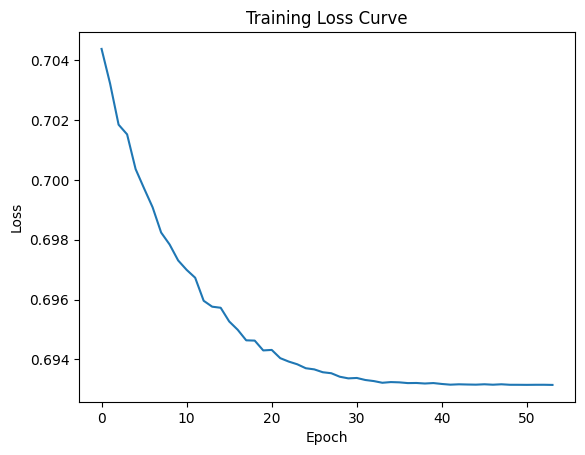

In [120]:
model = SimpleCNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
patience = 5
min_delta = 1e-5
counter = 0
loss_prev = float('inf')

losses = []
loss_prev=0
for epoch in range(100):
    epoch_loss = 0
    for images, masks in loader:
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
        
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    
    if abs(loss_prev - avg_loss) < min_delta:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    else:
        counter = 0

    loss_prev = avg_loss
    
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()